# Synthetic scRNA-seq GRN: simulate & visualize

This notebook uses `iqcell.simulation` to build a small but biologically motivated **gene regulatory network (GRN)** from early haematopoiesis, simulate scRNA-seq-like expression along pseudotime, and visualize both the network and the data.

**Biology modelled (erythroid vs. myeloid branch):**
- **GATA1** and **TAL1/SCL** are co-expressed early and together (an **AND** gate) switch on the erythroid master gene **KLF1 (EKLF)**. Cooperative GATA1+TAL1 activation of erythroid genes is well documented.
- Later in pseudotime the myeloid factor **SPI1 (PU.1)** rises and **represses KLF1**, reflecting the classic GATA1–PU.1 antagonism that resolves the erythroid/myeloid fate decision.
- **CCNB1 (Cyclin B1)** is an independent **cell-cycle** gene that oscillates on/off several times and is **not** wired into the KLF1 circuit — a realistic distractor for inference.

Because the topology is known, this is a ground-truth benchmark for the iqcell inference modules (binarization → gene hierarchy → logic engine).

## Setup

In [1]:
import os, sys
# Make the repo root importable when running from examples/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.insert(0, os.path.abspath(os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from iqcell.simulation import (
    GRNSpec, HillParams, SyntheticGRNGenerator, NoiseConfig, RootSignal,
)

np.random.seed(0)
print('imports ok')

imports ok


## 1. Define the ground-truth GRN

`GATA1`, `TAL1`, `SPI1`, and `CCNB1` are **root driver** genes (no upstream regulators) — we set their expression timing explicitly. `KLF1` is the only regulated gene: activated by GATA1 **and** TAL1, repressed by SPI1.

```
GATA1 -> KLF1   (activator)
TAL1  -> KLF1   (activator)   <- both required (AND)
SPI1  -| KLF1   (repressor, comes on later)
CCNB1  :  isolated oscillator (no edges)
```

In [2]:
genes = ['GATA1', 'TAL1', 'SPI1', 'KLF1', 'CCNB1']
spec = GRNSpec(genes)
# KLF1 needs BOTH activators (multiplicative Hill = AND) and is shut off by SPI1.
spec.set_rule(
    'KLF1',
    activators=['GATA1', 'TAL1'],
    repressors=['SPI1'],
    hill={
        'GATA1': HillParams(K=0.4, n=6.0),
        'TAL1':  HillParams(K=0.4, n=6.0),
        'SPI1':  HillParams(K=0.3, n=8.0),  # sharp switch-off
    },
)
spec.validate()

print('roots      :', spec.roots())
print('topo order :', spec.topological_order())
print('edges (regulator, target, sign):')
for e in spec.edges():
    print('  ', e)

roots      : ['GATA1', 'TAL1', 'SPI1', 'CCNB1']
topo order : ['GATA1', 'TAL1', 'SPI1', 'CCNB1', 'KLF1']
edges (regulator, target, sign):
   ('GATA1', 'KLF1', 1)
   ('TAL1', 'KLF1', 1)
   ('SPI1', 'KLF1', -1)


### Signed adjacency matrix
Rows = regulator, columns = target. `+1` = activation, `-1` = repression, `0` = no edge (note CCNB1's row/column are all zero).

In [3]:
adj_df = pd.DataFrame(spec.adjacency(), index=genes, columns=genes)
adj_df

,GATA1,TAL1,SPI1,KLF1,CCNB1
GATA1,0,0,0,1,0
TAL1,0,0,0,1,0
SPI1,0,0,0,-1,0
KLF1,0,0,0,0,0
CCNB1,0,0,0,0,0


## 2. Visualize the GRN graph (circular layout)
Green arrows = activation, red bracket-heads = repression. Yellow nodes are root drivers; the grey node (CCNB1) is the isolated oscillator.

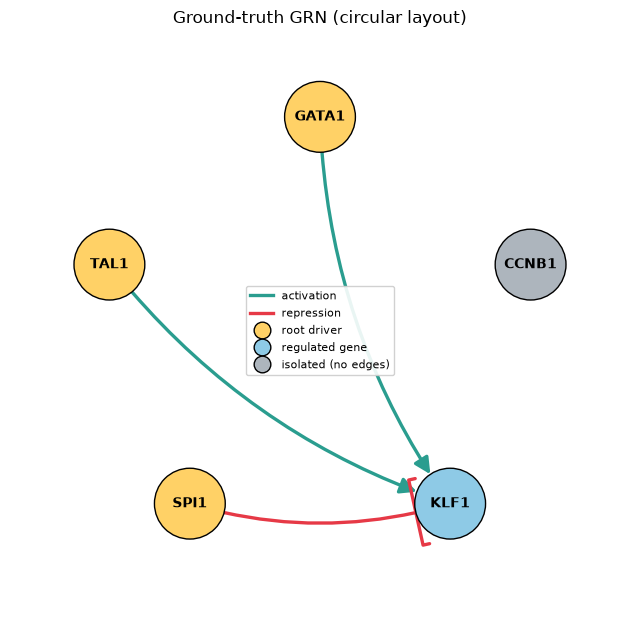

In [4]:
def draw_grn_circular(spec, ax=None, seed=3):
    G = nx.DiGraph()
    G.add_nodes_from(spec.genes)
    for reg, tgt, sign in spec.edges():
        G.add_edge(reg, tgt, sign=sign)

    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 6.5))

    # Circular layout, ordered so wired genes sit together and the
    # isolated oscillator is placed on its own arc.
    ordered = [g for g in spec.genes if any(g in (u, v)
               for u, v in G.edges())]
    isolated = [g for g in spec.genes if g not in ordered]
    node_order = ordered + isolated
    pos = nx.circular_layout(G.subgraph(node_order))
    # circular_layout ignores order; rebuild deterministically around a circle
    import numpy as _np
    N = len(node_order)
    pos = {g: _np.array([_np.cos(2*_np.pi*i/N + _np.pi/2),
                          _np.sin(2*_np.pi*i/N + _np.pi/2)])
           for i, g in enumerate(node_order)}

    act = [(u, v) for u, v, s in G.edges(data='sign') if s > 0]
    rep = [(u, v) for u, v, s in G.edges(data='sign') if s < 0]
    roots = set(spec.roots())
    wired = set(ordered)
    colors = []
    for g in G.nodes:
        if g not in wired:
            colors.append('#adb5bd')       # isolated
        elif g in roots:
            colors.append('#ffd166')       # root driver
        else:
            colors.append('#8ecae6')       # regulated

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2600,
                           edgecolors='black', ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=act, edge_color='#2a9d8f',
                           width=2.4, arrowsize=24, node_size=2600,
                           connectionstyle='arc3,rad=0.15', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=rep, edge_color='#e63946',
                           width=2.4, arrowsize=24, arrowstyle='-[',
                           node_size=2600,
                           connectionstyle='arc3,rad=0.15', ax=ax)

    from matplotlib.lines import Line2D
    legend = [
        Line2D([0], [0], color='#2a9d8f', lw=2.4, label='activation'),
        Line2D([0], [0], color='#e63946', lw=2.4, label='repression'),
        Line2D([0], [0], marker='o', color='w', label='root driver',
               markerfacecolor='#ffd166', markeredgecolor='black', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='regulated gene',
               markerfacecolor='#8ecae6', markeredgecolor='black', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='isolated (no edges)',
               markerfacecolor='#adb5bd', markeredgecolor='black', markersize=12),
    ]
    ax.legend(handles=legend, loc='center', fontsize=8, framealpha=0.9)
    ax.set_title('Ground-truth GRN (circular layout)')
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_axis_off()
    return ax

draw_grn_circular(spec)
plt.tight_layout()
plt.show()

## 3. Simulate scRNA-seq-like data

We drive the root genes with explicit pulse timing via `RootSignal`:
- **GATA1** and **TAL1** peak **early** and overlap → their AND turns KLF1 ON.
- **SPI1** peaks **later** → it represses KLF1, switching it OFF.
- **CCNB1** fires **three pulses** (cell cycle) and is disconnected.

Downstream KLF1 follows Hill dynamics with a regulatory lag (`reg_skip`), then biological noise and dropout are added.

In [10]:
root_signals = {
    'GATA1': RootSignal(centers=[0.35], width=0.13, amp=1.0),
    'TAL1':  RootSignal(centers=[0.40], width=0.13, amp=1.0),
    'SPI1':  RootSignal(centers=[0.45], width=0.1, amp=0.5),
    'CCNB1': RootSignal(centers=[0.15, 0.45, 0.75], width=0.045, amp=1.0),
}

gen = SyntheticGRNGenerator(
    spec,
    n_cells=600,
    reg_skip=8,
    noise=NoiseConfig(biological=0.05, dropout=0.2),
    root_signals=root_signals,
    seed=0,
).simulate()

print('clean expression :', gen.clean.shape)
print('noisy expression :', gen.expression.shape)

clean expression : (600, 5)
noisy expression : (600, 5)


### Clean vs. noisy continuous expression
Watch the logic: KLF1 (thick black) rises only while **both** GATA1 and TAL1 are high, then collapses when SPI1 comes on. CCNB1 oscillates independently.

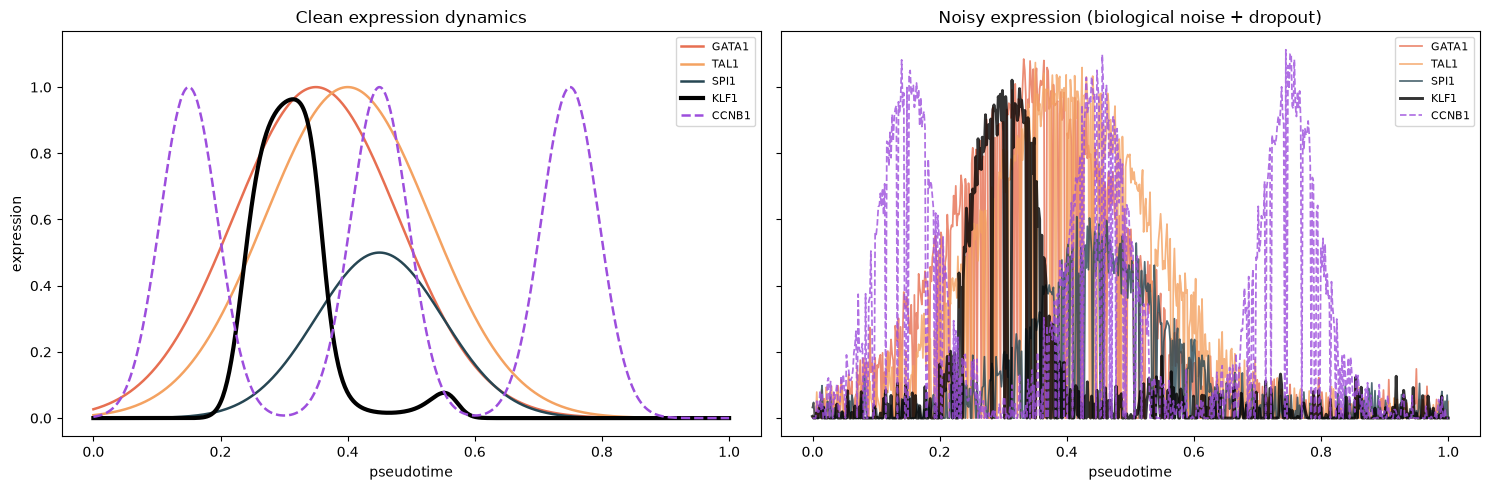

In [11]:
color = {'GATA1': '#e76f51', 'TAL1': '#f4a261', 'SPI1': '#264653',
         'KLF1': 'black', 'CCNB1': '#9d4edd'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for j, g in enumerate(genes):
    lw = 3 if g == 'KLF1' else 1.8
    ls = '--' if g == 'CCNB1' else '-'
    axes[0].plot(gen.pseudotime, gen.clean[:, j], label=g, lw=lw, ls=ls,
                 color=color[g])
    axes[1].plot(gen.pseudotime, gen.expression[:, j], label=g, lw=lw*0.7,
                 ls=ls, color=color[g], alpha=0.8)
axes[0].set_title('Clean expression dynamics')
axes[1].set_title('Noisy expression (biological noise + dropout)')
for ax in axes:
    ax.set_xlabel('pseudotime'); ax.legend(fontsize=8)
axes[0].set_ylabel('expression')
plt.tight_layout(); plt.show()

### Expression heatmap (genes × cells)
Cells ordered by pseudotime along the x-axis.

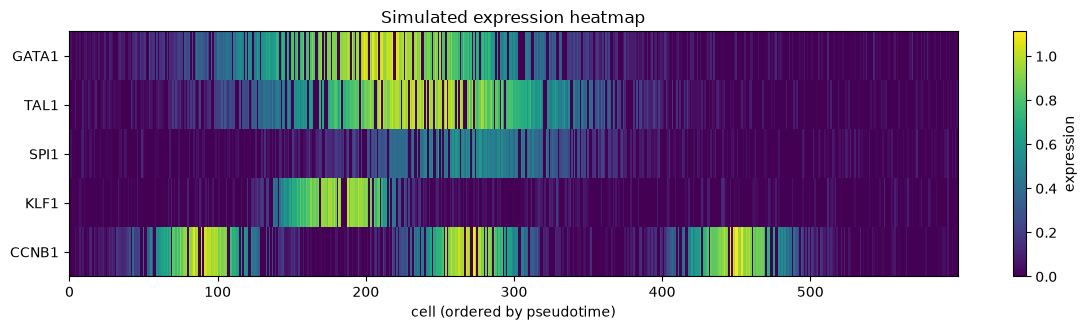

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.4))
im = ax.imshow(gen.expression.T, aspect='auto', cmap='viridis',
               interpolation='nearest')
ax.set_yticks(range(len(genes))); ax.set_yticklabels(genes)
ax.set_xlabel('cell (ordered by pseudotime)')
ax.set_title('Simulated expression heatmap')
fig.colorbar(im, ax=ax, label='expression')
plt.tight_layout(); plt.show()

## 4. Outputs for the iqcell pipeline
`to_anndata()` returns a pipeline-ready AnnData (binary `X`, continuous `raw.X`, pseudotime in `obs`, ground-truth GRN in `uns`).

In [16]:
adata = gen.to_anndata(binarize=True)
print(adata)
print('\nbinarized X unique values:', np.unique(adata.X))
print('raw.X range :', round(float(adata.raw.X.min()), 3),
      '..', round(float(adata.raw.X.max()), 3))

AnnData object with n_obs × n_vars = 600 × 5
    obs: 'pseudotime'
    uns: 'grn_adjacency', 'grn_genes'
    layers: None (.X), 'clean'

binarized X unique values: [0. 1.]
raw.X range : 0.0 .. 1.113


### Binarized ON/OFF states
Note KLF1's ON window sits between the activator peak and the repressor peak, and CCNB1 blinks on/off three times.

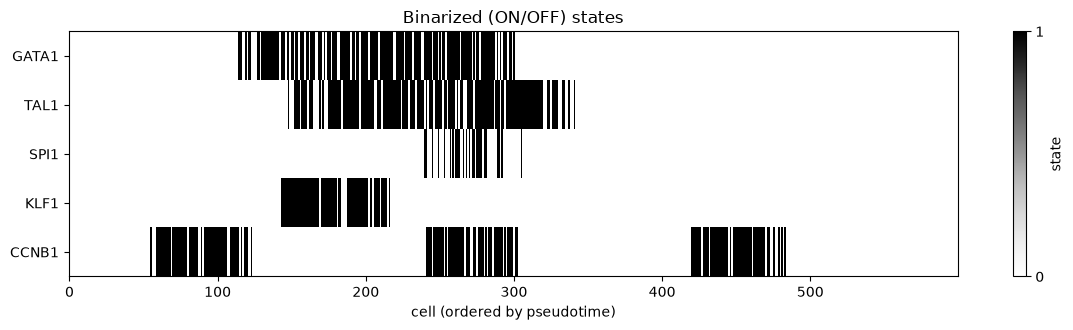

In [17]:
fig, ax = plt.subplots(figsize=(12, 3.4))
im = ax.imshow(adata.X.T, aspect='auto', cmap='Greys',
               interpolation='nearest', vmin=0, vmax=1)
ax.set_yticks(range(len(genes))); ax.set_yticklabels(genes)
ax.set_xlabel('cell (ordered by pseudotime)')
ax.set_title('Binarized (ON/OFF) states')
fig.colorbar(im, ax=ax, label='state', ticks=[0, 1])
plt.tight_layout(); plt.show()

### Tensors for the SINN And/Or logic engine
`to_tensors('KLF1')` returns `(x_act, x_rep, y, t)` matching `iqcell.utils.dataset.ExpressionData_And_Or`.

In [10]:
x_act, x_rep, y, t = gen.to_tensors('KLF1', binarize=True)
print('target = KLF1')
print('  x_act (activators GATA1, TAL1):', tuple(x_act.shape))
print('  x_rep (repressor SPI1)        :', tuple(x_rep.shape))
print('  y     (target KLF1)           :', tuple(y.shape))
print('  t     (pseudotime)            :', tuple(t.shape))

target = KLF1
  x_act (activators GATA1, TAL1): (600, 2)
  x_rep (repressor SPI1)        : (600, 1)
  y     (target KLF1)           : (600, 1)
  t     (pseudotime)            : (600, 1)


## Summary

- Built a biologically motivated GRN: **GATA1 AND TAL1 → KLF1**, later **SPI1 ⊣ KLF1**, plus an isolated oscillating cell-cycle gene **CCNB1**.
- Drew it with a **circular layout** (activation vs. repression, node roles).
- Simulated continuous + binarized scRNA-seq-like data showing the AND-gated activation and the delayed repression.
- Exported pipeline-ready `AnnData` and SINN-ready torch tensors.

The known topology makes this a ground-truth benchmark for iqcell inference.